In [3]:
!pip install astroML

In [79]:
import numpy as np

# import torch
from astroML import time_series
from astropy.cosmology import FlatLambdaCDM
from astropy import constants as const

import matplotlib.pyplot as plt
import pandas as pd

In [6]:
def DRW_params(
    logMbh: float,
    logMdot: float,
    z: float,
    wavelength: float = 4000.0,
    eta: float = 0.1,
) -> tuple[float, float, float]:
    """
    Calculate Damped Random Walk parameters based on AGN properties.

    Parameters
    ----------
    logMbh : float
        Log10 of black hole mass in solar masses
    logMdot : float
        Log10 of accretion rate in solar masses/year
    z : float
        Redshift
    wavelength : float, optional
        Observed wavelength in Angstroms (default: 4000)

    Returns
    -------
    tuple[float, float, float]
        (Structure function at infinity,
         DRW characteristic timescale,
         Absolute magnitude in i-band)
    """

    # Mdot -> Lbol -> L5100 -> Mi following Richards+2006
    Lbol = (
        eta
        * (10**logMdot)
        * 2e33
        / (365 * 60 * 60 * 24)
        * ((const.c.value * 1e2 * 10) ** 2)
    )  ## in erg/s
    lum5100 = 0.1 * Lbol  ## erg/s
    lum2500 = (lum5100 / 5100e-10) * (2500 / 5100) ** 0.5 * (2500e-10)  ## erg/s
    Mi_z2 = (
        np.log10(
            lum2500
            / ((const.c.value * 1e2 * 10) / 2500e-10)
            / 4
            / np.pi
            / (3.08e19) ** 2
        )
        / (-0.4)
        - 48.6
        - 2.5 * np.log10(1 + 2)
    )
    Mi = Mi_z2 + 0.596

    ## from MacLeod+2010 Equation 7 / Table 1
    params_SF = [-0.57, -0.479, 0.117, 0.11, 0.07]
    params_tau = [2.4, 0.17, -0.05, 0.12, -0.7]

    SF_inf = 10 ** (
        params_SF[0]
        + params_SF[1] * np.log10(wavelength / 4000.0)
        + params_SF[2] * (Mi + 23)
        + params_SF[3] * np.log10(10**logMbh / 1e9)
        + params_SF[4] * np.log10(1 + z)
    )
    tau_drw = 10 ** (
        params_tau[0]
        + params_tau[1] * np.log10(wavelength / 4000.0)
        + params_tau[2] * (Mi + 23)
        + params_tau[3] * np.log10(10**logMbh / 1e9)
        + params_tau[4] * np.log10(1 + z)
    )

    return SF_inf, tau_drw, Mi

In [15]:
wavelength = np.array([3751, 4740, 6172, 7500, 8678, 9711])
logMbh = 8
logMdot = 0
z = 0.1
eta = 0.1
baseline = 200.0
lc_time = np.arange(0, 3 * baseline, 0.1)

In [16]:
sf_inf, tau_drw, Mi = DRW_params(logMbh, logMdot, z, wavelength=wavelength[0], eta=eta)

## calculate flux following Richard+2006
color = (
    2.5 * (-0.5) * np.log10(wavelength / 7471)
)  ## simple SED slope for color if not specified

cosmo = FlatLambdaCDM(H0=70, Om0=0.3, Tcmb0=2.725)
mag_arr = (Mi + color) + 5 * np.log10(cosmo.luminosity_distance(z).value * 1e6) - 5

## make DRW
lc_flux = time_series.generate_damped_RW(lc_time, tau=tau_drw, z=z, SFinf=sf_inf)

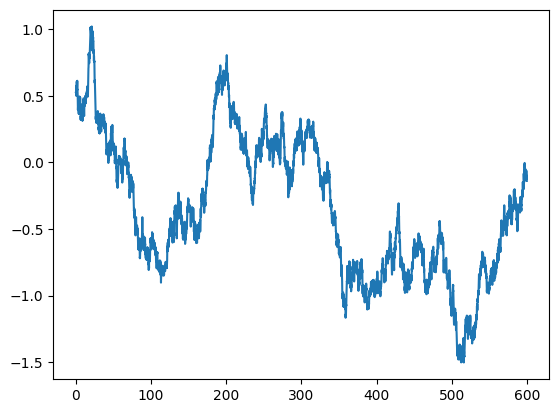

In [20]:
plt.plot(lc_time, lc_flux)

In [24]:
def lag_function(lag0, slope):
    waves = np.array([3751.0, 4740.0, 6172.0, 7500.0, 8678.0, 9711.0])
    lags = lag0 * (waves**slope - waves[0] ** slope)
    return lags

In [45]:
lags = lag_function(0.5, 0.5)
print(lags)

[ 0.          3.80112496  8.65833469 12.67856619 15.95518776 18.64949912]


In [49]:
t_start = np.round(np.random.uniform(0.5 * baseline, 3 * baseline - baseline))
t_start

307.0

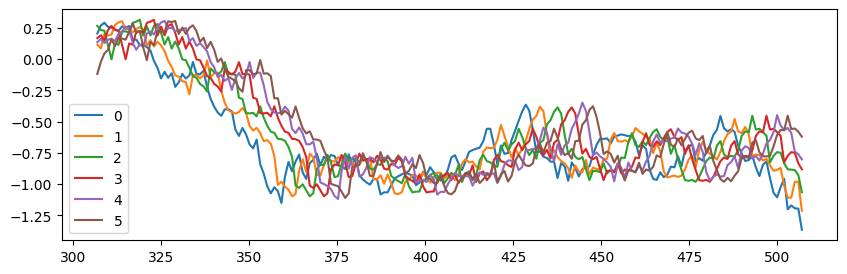

In [63]:
plt.figure(figsize=(10, 3))
for i in range(len(wavelength)):
    new_time = np.linspace(t_start, t_start + 200, 200)
    lc_flux_shift = np.interp(new_time - lags[i], lc_time, lc_flux)

    plt.plot(new_time, lc_flux_shift, label=[i])

plt.legend()

In [60]:
len(new_time)

200

In [65]:
mag_arr

array([19.15185309, 19.02481399, 18.88150453, 18.77571034, 18.69651236,
       18.63545698])

## make 100 examples

In [152]:
nlc = 100

df_all = pd.DataFrame({"ID": {}, "time": {}, "band": {}, "mag": {}, "lag": {}})
df_all["ID"] = np.arange(nlc, dtype=int)

wavelength = np.array([3751, 4740, 6172, 7500, 8678, 9711])  ## LSST bands
baseline = 200.0  ## baseline
lc_time = np.arange(0, 3 * baseline, 0.1)  ## random long light curve for downsampling

## fix all BH parameters?
logMbh = 8
logMdot = 0
z = 0.1
sf_inf, tau_drw, Mi = DRW_params(logMbh, logMdot, z, wavelength=wavelength[0], eta=eta)
lags = lag_function(0.5, 0.5)
color = (
    2.5 * (-0.5) * np.log10(wavelength / 7471)
)  ## simple SED slope for color if not specified
cosmo = FlatLambdaCDM(H0=70, Om0=0.3, Tcmb0=2.725)
mag_arr = (Mi + color) + 5 * np.log10(cosmo.luminosity_distance(z).value * 1e6) - 5

df_all["cos_inc"] = 0.866
df_all["logMbh"] = logMbh
df_all["logMdot"] = logMdot
df_all["redshift"] = z
df_all["lag"] = list(np.tile(lags, (nlc, 1)))

time_all = list([])
mag_all = list([])
band_all = list([])

for nn in range(nlc):
    ## make DRW
    lc_flux = time_series.generate_damped_RW(lc_time, tau=tau_drw, z=z, SFinf=sf_inf)

    t_start = np.round(np.random.uniform(0.5 * baseline, 3 * baseline - baseline))
    time = []
    mag = []
    band = []
    for i in range(len(wavelength)):
        new_time = np.linspace(t_start, t_start + 199, 200)
        lc_mag_shift = np.interp(new_time - lags[i], lc_time, lc_flux)
        lc_mag_shift = lc_mag_shift - np.median(lc_mag_shift) + mag_arr[i]

        time.append(new_time)
        mag.append(lc_mag_shift)
        band.append(np.zeros(len(new_time)) + i)

    time = time - np.min(time)

    time_all.append(np.array(time).T.flatten())
    mag_all.append(np.array(mag).T.flatten())
    band_all.append(np.array(band).T.flatten())


df_all["time"] = time_all
df_all["mag"] = mag_all
df_all["band"] = band_all

In [151]:
# df_all

## save to nested format

In [153]:
import nested_pandas as npd

df_nf = npd.NestedFrame(df_all)

In [154]:
df_nf = df_nf.nest_lists(columns=["time", "band", "mag"], name="light_curve")

In [155]:
df_nf

ID                                                lag  cos_inc  logMbh  \
0    0  [0.0, 3.801124960551892, 8.658334687239591, 12...    0.866       8   
1    1  [0.0, 3.801124960551892, 8.658334687239591, 12...    0.866       8   
..  ..                                                ...      ...     ...   
98  98  [0.0, 3.801124960551892, 8.658334687239591, 12...    0.866       8   
99  99  [0.0, 3.801124960551892, 8.658334687239591, 12...    0.866       8   

    logMdot  redshift                                        light_curve  
0         0       0.1  [{time: 0.0, band: 0.0, mag: 19.218005}; …] (1...  
1         0       0.1  [{time: 0.0, band: 0.0, mag: 19.096767}; …] (1...  
..      ...       ...                                                ...  
98        0       0.1  [{time: 0.0, band: 0.0, mag: 19.213286}; …] (1...  
99        0       0.1  [{time: 0.0, band: 0.0, mag: 18.699032}; …] (1...  

[100 rows x 7 columns]

In [156]:
df_nf.to_parquet("lightcurve_deltalag_fixed_nested.parquet")

## plot examples

In [157]:
def plot_lc(time, mag, band, magerr=None):
    unique_band, cnts = np.unique(band, return_counts=True)

    time_by_band = np.zeros((len(unique_band), max(cnts)))
    mag_by_band = np.zeros((len(unique_band), max(cnts)))
    magerr_by_band = np.zeros((len(unique_band), max(cnts)))

    for ib, b in enumerate(unique_band):
        ind = np.where(band == b)[0]
        time_by_band[ib, : len(ind)] = time[ind]
        mag_by_band[ib, : len(ind)] = mag[ind]
        if magerr != None:
            magerr_by_band[ib, : len(ind)] = magerr[ind]

    plt.figure(figsize=(10, 5))
    for i in range(time_by_band.shape[0]):
        plt.errorbar(time_by_band[i], mag_by_band[i], yerr=magerr_by_band[i], ls="-")

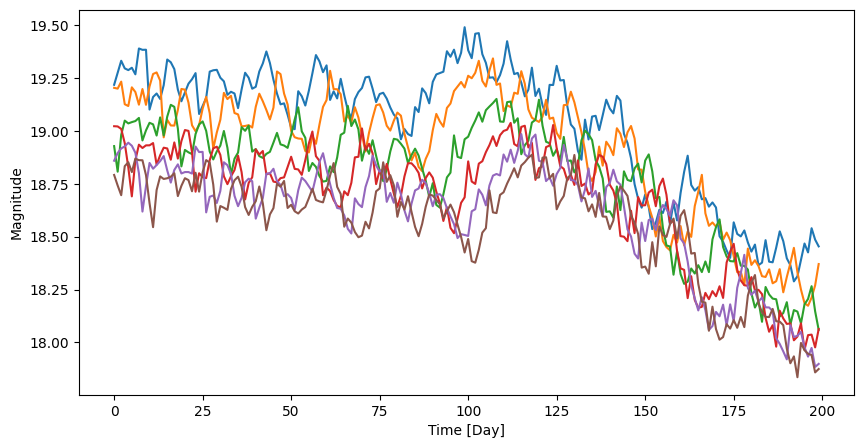

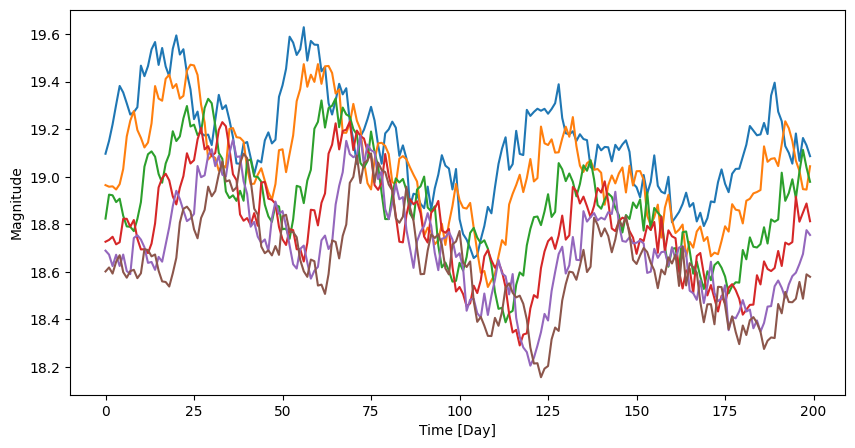

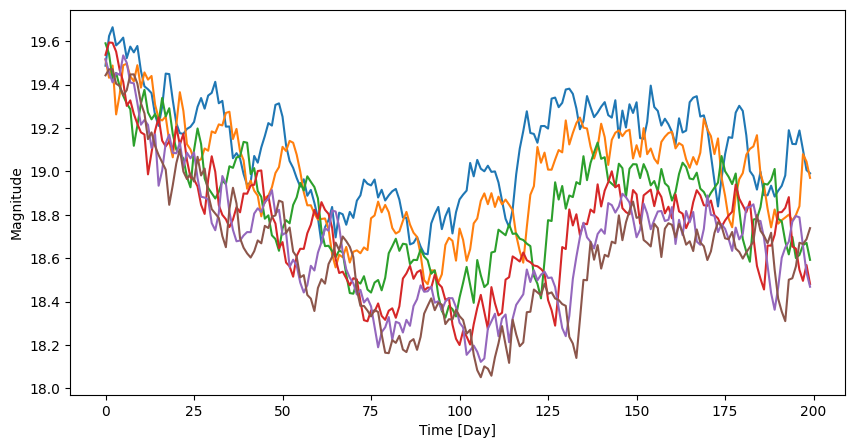

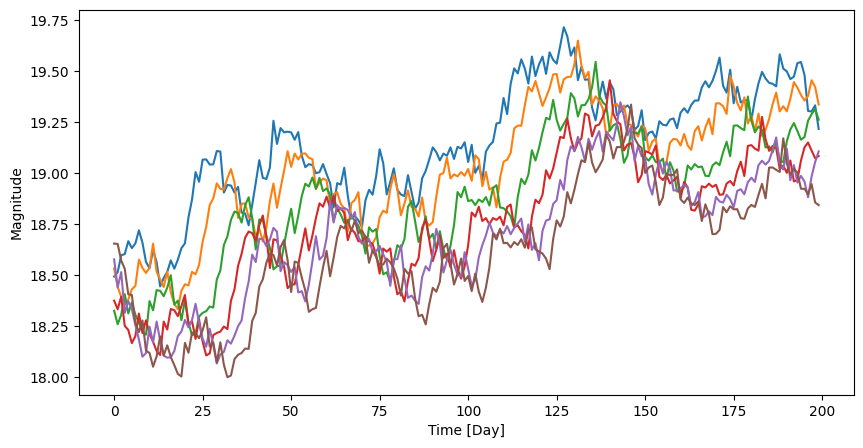

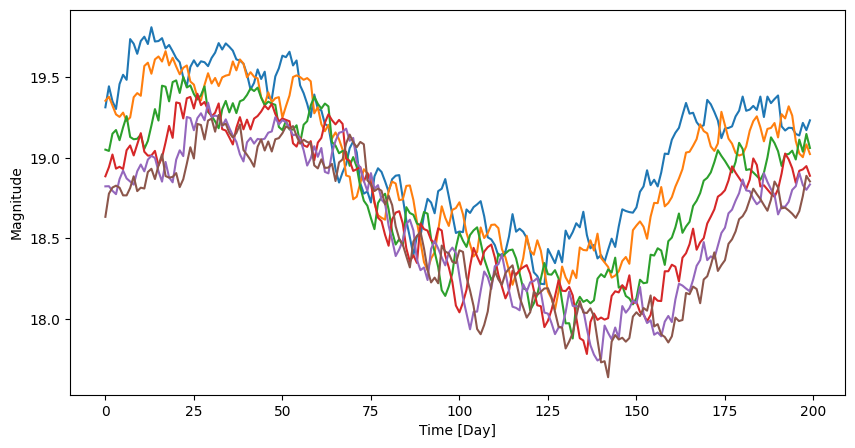

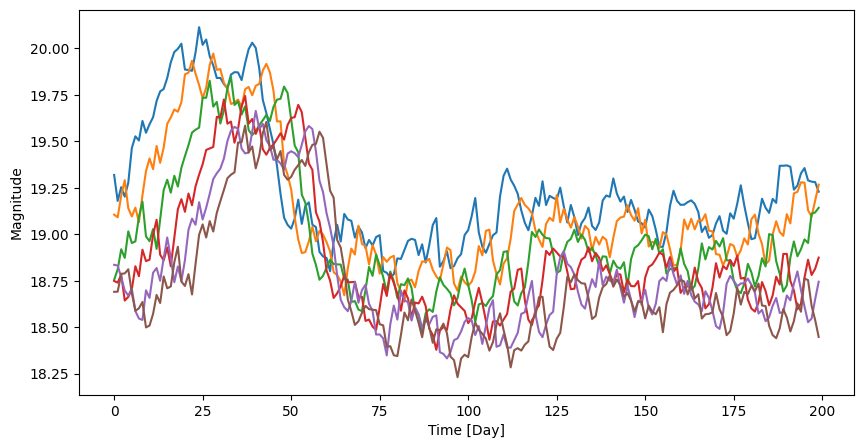

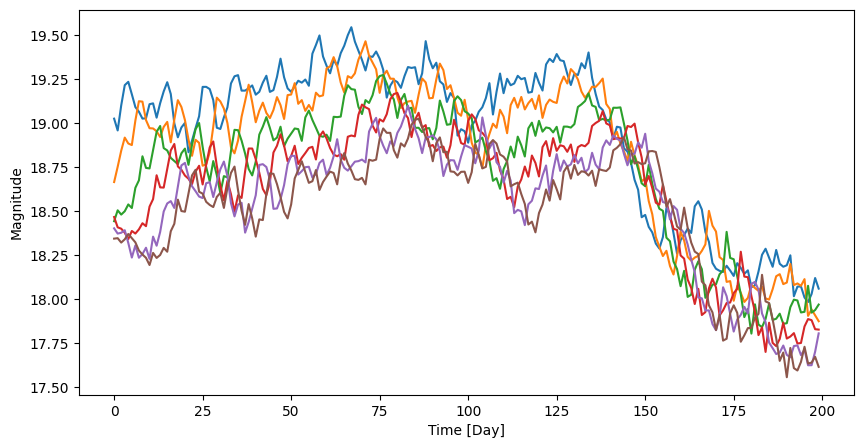

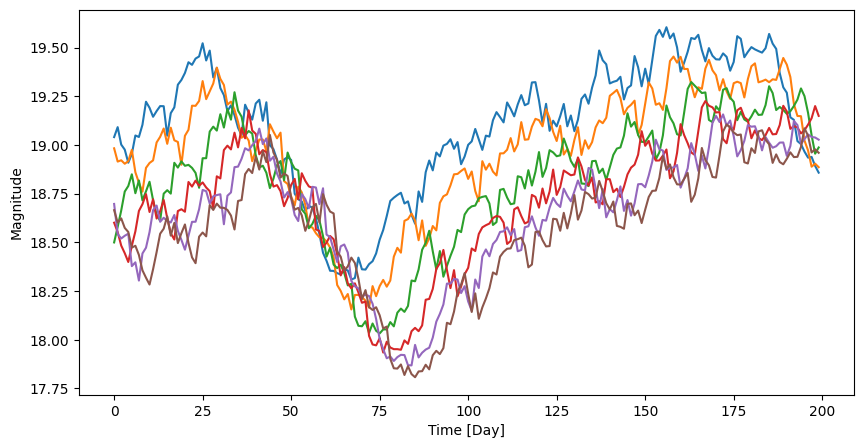

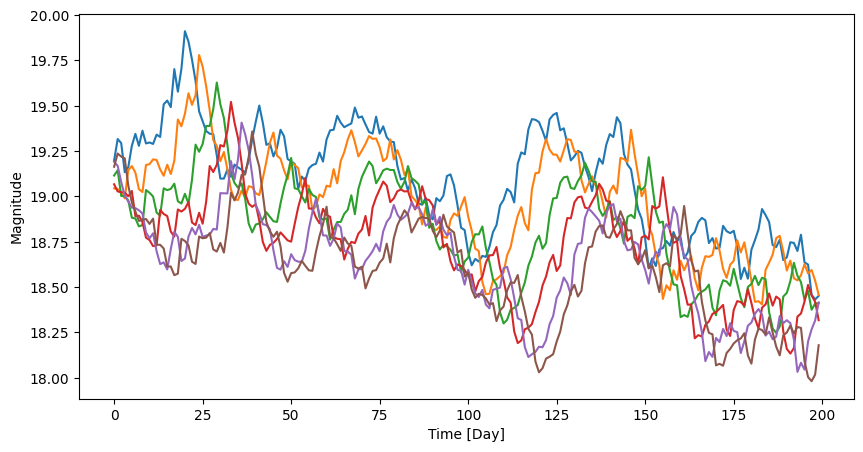

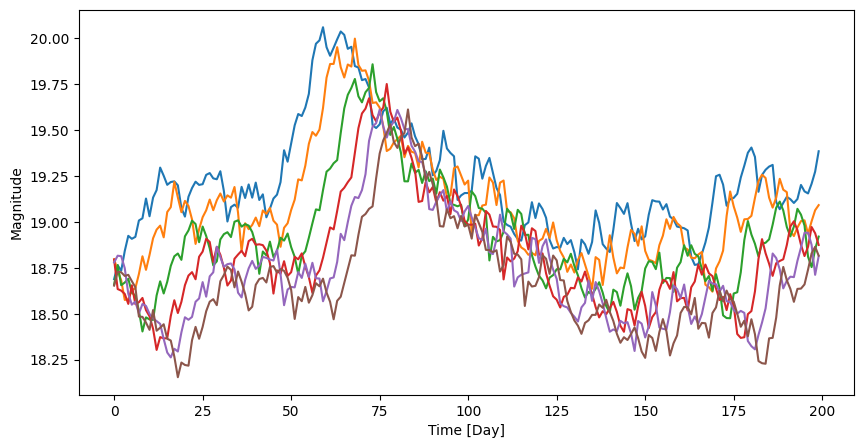

In [158]:
for idx in range(10):
    plot_lc(df_all["time"][idx], df_all["mag"][idx], df_all["band"][idx], magerr=None)
    plt.xlabel("Time [Day]")
    plt.ylabel("Magnitude")

In [159]:
sf_inf, tau_drw

(0.5513092180437074, 118.34462112809231)